In [1]:
# # %%capture

# # Install the PyBolt package directly from Github
# %pip install git+https://github.com/Maxim-Laletin/PyBolt.git@setup-package

# # Install the torch
# %pip install torch

# # Install pandas
# %pip install pandas

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from PyBolt import fBE_solver as fBE
import time
from parameters import g_m1, Msq, m1, m2, mDM, g_x, Gamma
from boltzmann import BoltzmaNN

# torch.set_default_dtype(torch.float64)

fBE solved in 0.07 seconds


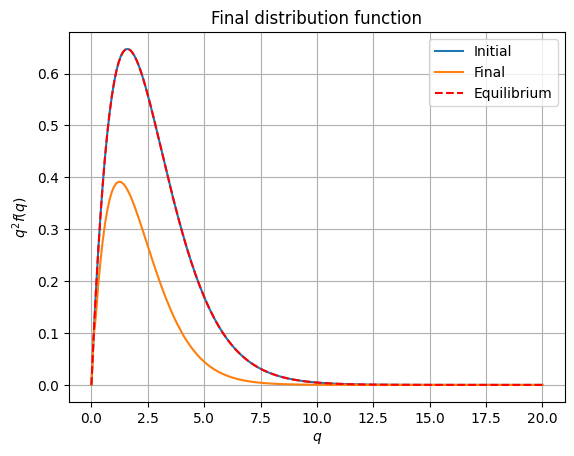

In [3]:
# Create a model of axion phase-space evolution
AxionModel = fBE.Model(m1,mDM,g_x,'b')
# m1 is the mass of the heaviest particle in the reaction

# Create an instance of the DecayToX process class
Decay = fBE.DecayToX(m1,m2,g_m1,Msq,Gamma)

# Create the grid of x and q
N_x = 500 # number of x points
N_q = 200 # number of q points
x0 = 6.0  # starting x value
xf = 20.0 # final x value

q0 = 0.0001 # smallest q value
qf = 20. # biggest q value

# Creating vectors of linearly distributed values of x and q
x_lin = np.linspace(x0,xf,N_x)
q_lin = np.linspace(q0,qf,N_q)

# Assigning the grid (of x and q) to the model
AxionModel.changeGrid(x_lin,q_lin)

# Add the decay collision integral to the model collision term (the only process that we consider)
AxionModel.addCollisionTerm(Decay.collisionTerm)

# Initial distribution
#f0 = np.zeros_like(q_lin)
f0 = AxionModel.equilibriumFunction(q_lin)

# fBE solver options
solver_options = {
    'method': 'BDF', # Implicit backward differentiation formula method of variable order (1-5) - because the equation is stiff
    'atol': 1e-5,   # Absolute tolerance
    'rtol': 1e-3   # Relative tolerance
}

# Solving the fBE
AxionModel.solve_fBE(f0,solver_options)
NumericalEvolution=AxionModel.getSolution()

NumericalFinalDistribution = NumericalEvolution[-1, :]

# Plot the initial and final solutions and the equilibrium distribution to compare
plt.figure()
plt.plot(q_lin,f0, label = 'Initial')
plt.plot(q_lin, AxionModel.getSolution()[-1,:], label = 'Final')
plt.plot(q_lin, AxionModel.equilibriumFunction(q_lin),'r--', label = 'Equilibrium')
plt.xlabel(r'$q$')
plt.ylabel(r'$q^2 f(q)$')
plt.title("Final distribution function")
plt.legend(loc="upper right")
plt.grid()
plt.show()


{'boundary': 0.0027371065225452185, 'initial': 0.0076020569540560246, 'physics': 0.0007251574981197952, 'positivity': 0.0, 'weighted_sum': 0.011064320974721039, 'last LR': 0.01}
Epoch 1000: MSE wrt numerical = 0.036111306503161904
{'boundary': 0.00015033813542686403, 'initial': 2.8437923901947215e-05, 'physics': 0.0003096933633443273, 'positivity': 0.0, 'weighted_sum': 0.0004884694226731385, 'last LR': 0.01}
Epoch 2000: MSE wrt numerical = 0.008275341954757293
{'boundary': 6.228415441000834e-05, 'initial': 0.00015097035793587565, 'physics': 0.0013389002053655367, 'positivity': 0.0, 'weighted_sum': 0.0015521547177114207, 'last LR': 0.01}
Epoch 3000: MSE wrt numerical = 0.006531735502516699
{'boundary': 0.001056679873727262, 'initial': 0.00018345020362176, 'physics': 0.001560396136049963, 'positivity': 0.0, 'weighted_sum': 0.0028005262133989853, 'last LR': 0.01}
Epoch 4000: MSE wrt numerical = 0.014973811442247605
{'boundary': 1.2711927865893813e-06, 'initial': 1.992422403418459e-05, 'ph

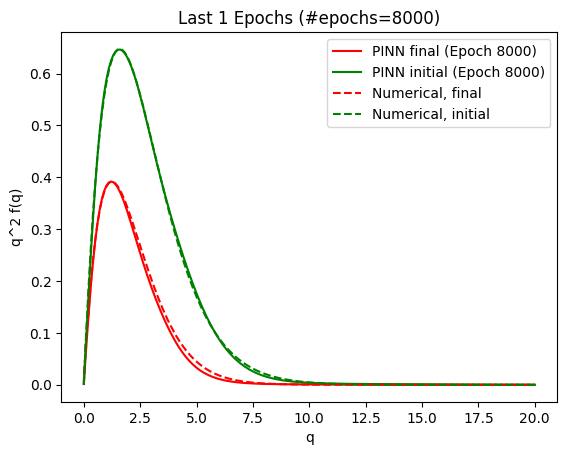

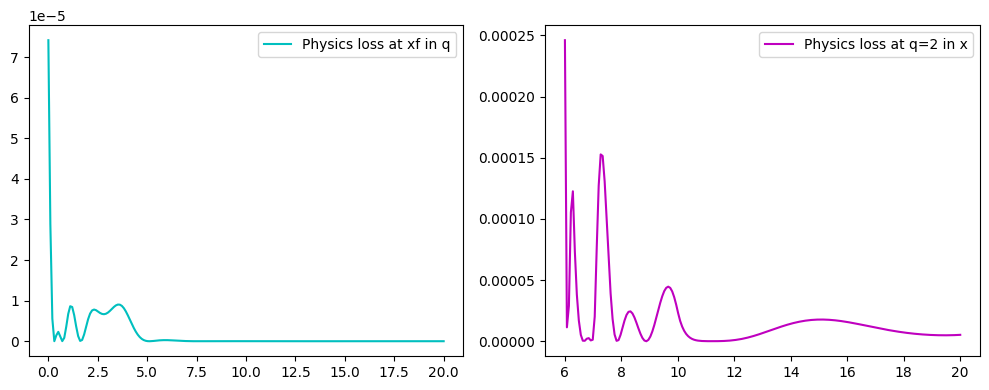

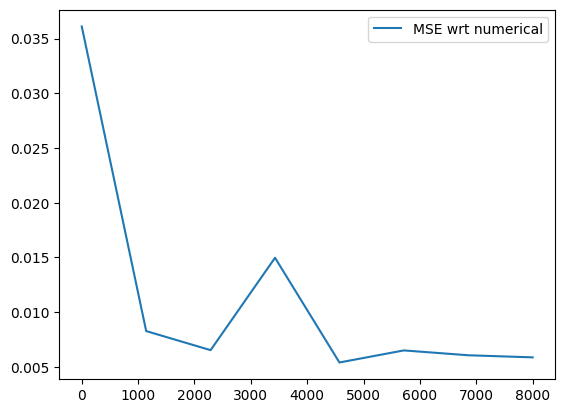

In [7]:
# Initialize the TrainingBoltzmaNN instance with the specified parameters
num_epochs=8001

train1 = BoltzmaNN(
    x_range=[x0,xf],
    q_range=[q0,qf],
    hidden_width=32,
    batch_size=25,
    collocation_number_plot=N_q,
    NumericalSolution=NumericalEvolution,
    q_lin_num=q_lin,
    x_lin_num=x_lin
)

# Train the network and measure the training time
start_time = time.time()
mse_nn_num, final_loss = train1.train(
    num_epochs,
    physics_weight=10,
    positivity_weight=0,
    bc_weight=1e-1,
    initialC_weight=1,
    patience=800,
    learning_rate=0.01
    )
end_time = time.time()
print('Learning time:', end_time - start_time, "\n\n")

# Plot the steps and learning data
# train1.plot_steps()
train1.plot_last(1)
train1.plot_learning_data(num_epochs)

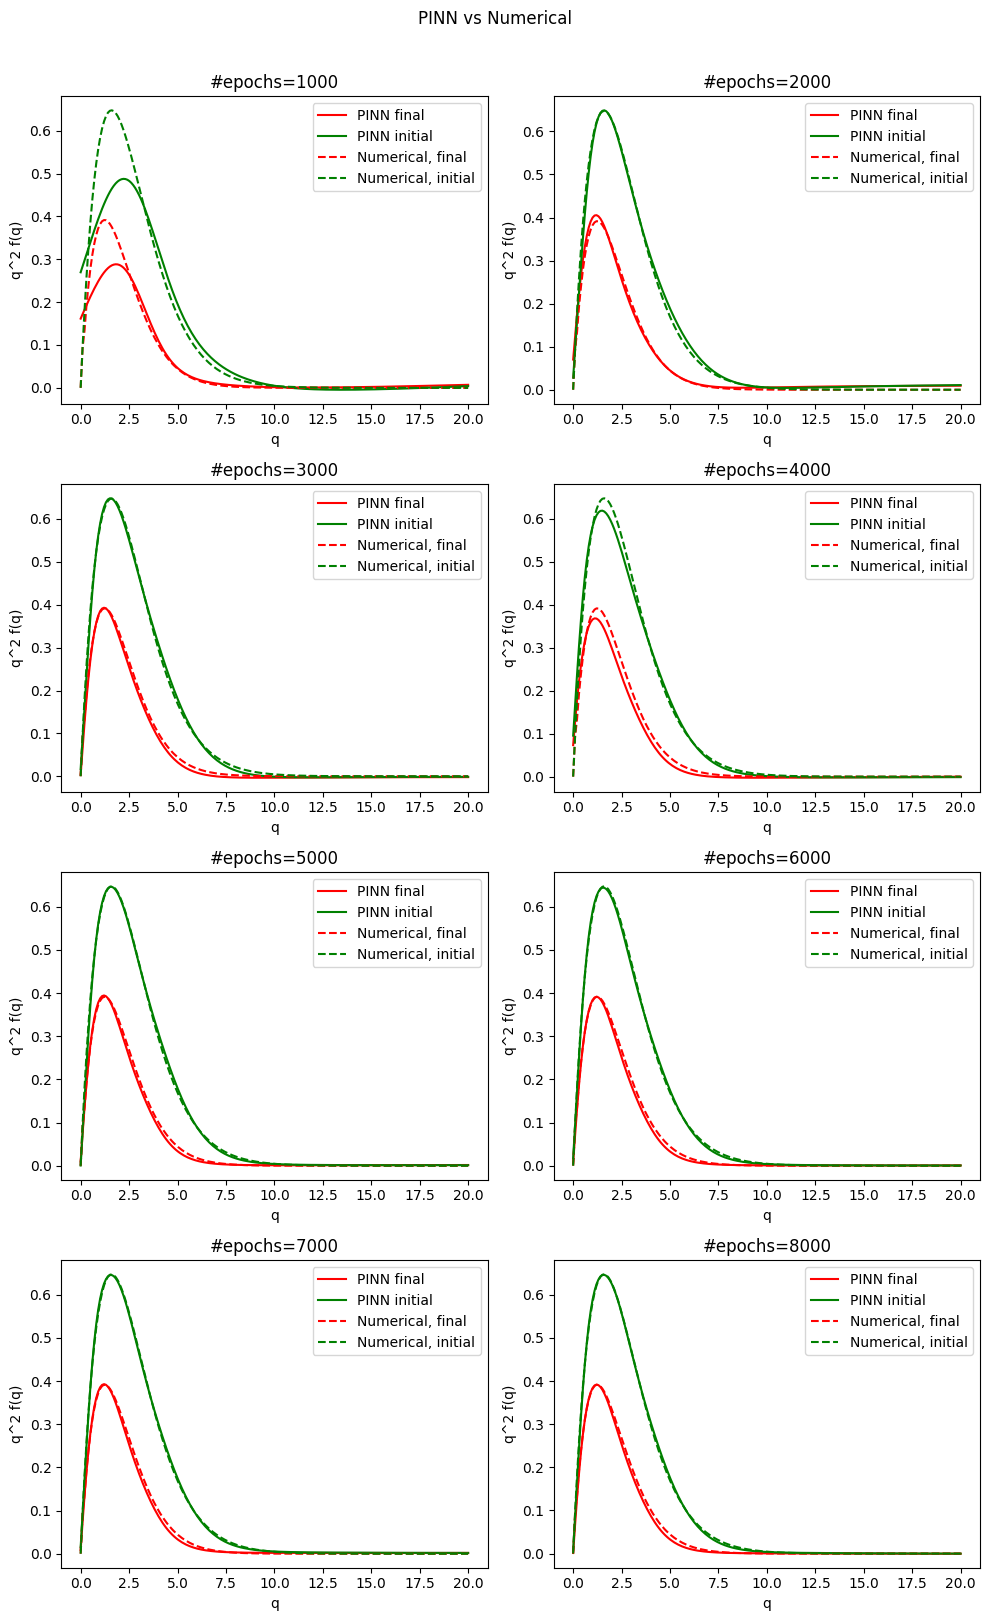

In [9]:
train1.plot_steps()
